# Step 1: Build and verify MITgcm

Before I change anything in the model, I need to know that my build of MITgcm on this Mac gives the same answer as the official reference run. In this notebook I check the tools, compare my short test run with the reference output line by line, look at the CFL numbers, and time a longer run to plan the spin-up.

The build and the runs were done with `scripts/build.sh` and `scripts/run_experiment.sh`. This notebook only reads their logs and output.

I load the libraries and set all paths in one place. The model source and every run live outside the git repo, so the paths point to my home folder.

In [1]:
%matplotlib inline

import os
import re
import math
import subprocess

import numpy as np
import matplotlib.pyplot as plt

HOME = os.path.expanduser("~")
MITGCM_ROOT = os.path.join(HOME, "models", "MITgcm")                     # MITgcm source code
TUTORIAL = os.path.join(MITGCM_ROOT, "verification", "tutorial_global_oce_latlon")
REF_OUTPUT = os.path.join(TUTORIAL, "results", "output.txt")              # official reference output
RUNS = os.path.join(HOME, "mitgcm_runs", "hosing")                        # all my runs
BUILD_IEEE = os.path.join(RUNS, "build_reference_ieee")                   # build with strict IEEE flags
BUILD_FAST = os.path.join(RUNS, "build_reference_fast")                   # build with optimized flags
RUN_IEEE = os.path.join(RUNS, "reference_test_ieee")                      # 20-step test, IEEE build
RUN_FAST = os.path.join(RUNS, "reference_test_fast")                      # 20-step test, fast build
TIMING_FAST = os.path.join(RUNS, "timing_2yr_fast")                       # 2-year timing run, fast build
TIMING_IEEE = os.path.join(RUNS, "timing_2yr_ieee")                       # 2-year timing run, IEEE build

SECONDS_PER_MODEL_YEAR = 31104000.0   # this setup uses a 360-day year (12 forcing months of 30 days)
DIGITS_IF_IDENTICAL = 16              # what I plot when two numbers agree in every printed digit
FIG_DIR = "../figures"
os.makedirs(FIG_DIR, exist_ok=True)

I check the machine and the tools. `uname -m` tells me the processor type, which decides the build-options file: `arm64` (Apple silicon) means `darwin_arm64_gfortran`.

In [2]:
def run_command(command):
    """Run a shell command and return its output as text."""
    return subprocess.run(command, shell=True, capture_output=True, text=True).stdout.strip()

print("processor (uname -m):", run_command("uname -m"))
print("gfortran:", run_command("gfortran --version | head -1"))
print("make:    ", run_command("make --version | head -1"))
print("MITgcm commit:", run_command(f"git -C {MITGCM_ROOT} log -1 --format='%H (%cd)'"))
print("MITgcm tag:   ", run_command(f"git -C {MITGCM_ROOT} describe --tags"))
print("build-options files for Macs:", run_command(f"ls {MITGCM_ROOT}/tools/build_options | grep darwin_.*gfortran"))

processor (uname -m): arm64
gfortran: GNU Fortran (Homebrew GCC 16.2.0) 16.2.0
make:     GNU Make 3.81
MITgcm commit: 853761d8f46926cd8042d6e0ad252050561fd6fa (Mon Aug 24 18:08:42 2026 -0400)
MITgcm tag:    checkpoint69q
build-options files for Macs: darwin_amd64_gfortran
darwin_arm64_gfortran
darwin_ia32_gfortran


I confirm that both builds produced an executable, and I show the optimization flags each one used. The IEEE build turns optimization off so the arithmetic is as close as possible to the reference machine.

In [3]:
for build in [BUILD_IEEE, BUILD_FAST]:
    exe = os.path.join(build, "mitgcmuv")
    flags = run_command(f"grep '^FOPTIM' {build}/Makefile")
    print(os.path.basename(build), "| executable exists:", os.path.exists(exe), "|", flags)

build_reference_ieee | executable exists: True | FOPTIM = -O0
build_reference_fast | executable exists: True | FOPTIM = -O3 -ftree-vectorize -funroll-loops


These are the key time-stepping and relaxation parameters from the tutorial's `data` file, exactly as provided. I explain each one in TUTORIAL.md.

In [4]:
keys = ["nIter0", "nTimeSteps", "deltaTmom", "deltaTtracer", "deltaTClock", "deltaTfreesurf",
        "pChkptFreq", "chkptFreq", "dumpFreq", "monitorFreq", "tauThetaClimRelax", "tauSaltClimRelax",
        "externForcingPeriod", "externForcingCycle", "useRealFreshWaterFlux", "EmPmRFile"]
for line in open(os.path.join(TUTORIAL, "input", "data")):
    stripped = line.strip()
    for key in keys:
        if stripped.startswith(key):
            print(stripped)

useRealFreshWaterFlux=.TRUE.,
nIter0=       0,
nTimeSteps = 20,
deltaTmom = 1800.,
deltaTtracer= 86400.,
deltaTClock = 86400.,
deltaTfreesurf= 86400.,
pChkptFreq= 1728000.,
dumpFreq=   864000.,
monitorFreq=1.,
tauThetaClimRelax=  5184000.,
tauSaltClimRelax = 15552000.,
externForcingPeriod=2592000.,
externForcingCycle=31104000.,
EmPmRFile=      'ncep_emp.bin',


This function reads every `%MON` (monitor) line from a model output file. Each line has a name and a value, and the model prints a full block of them at every monitor time.

In [5]:
def read_monitor(path):
    """Return a dictionary: monitor name -> list of values, one per monitor time."""
    values = {}
    for line in open(path):
        match = re.search(r"%MON (\S+)\s+=\s+(\S+)", line)
        if match is None:
            continue
        name = match.group(1)
        try:
            number = float(match.group(2).replace("D", "E"))   # Fortran may print 1.0D+00
        except ValueError:
            continue
        if name not in values:
            values[name] = []
        values[name].append(number)
    return values

ref = read_monitor(REF_OUTPUT)
ours_ieee = read_monitor(os.path.join(RUN_IEEE, "output.txt"))
ours_fast = read_monitor(os.path.join(RUN_FAST, "output.txt"))
print("monitor quantities: reference", len(ref), "| IEEE build", len(ours_ieee), "| fast build", len(ours_fast))
print("monitor times per quantity (reference):", len(ref["time_tsnumber"]))

monitor quantities: reference 165 | IEEE build 165 | fast build 165
monitor times per quantity (reference): 21


This function measures how many significant digits two runs share, the same idea MITgcm's own `testreport` uses. For each quantity I keep the worst agreement over all monitor times.

In [6]:
def matching_digits(ours, reference):
    """Smallest number of matching significant digits over all monitor times."""
    worst = DIGITS_IF_IDENTICAL
    for a, b in zip(ours, reference):
        if a == b:
            continue
        relative_difference = abs(a - b) / max(abs(a), abs(b))
        digits = -math.log10(relative_difference)
        worst = min(worst, digits)
    return worst


def compare(ours, reference):
    """Matching digits for every quantity in the reference, sorted from worst to best."""
    result = []
    for name in reference:
        if name not in ours or len(ours[name]) != len(reference[name]):
            result.append((-1.0, name))     # missing or different length: flag it as a failure
            continue
        result.append((matching_digits(ours[name], reference[name]), name))
    result.sort()
    return result

cmp_ieee = compare(ours_ieee, ref)
cmp_fast = compare(ours_fast, ref)
for label, cmp in [("IEEE build", cmp_ieee), ("fast build", cmp_fast)]:
    identical = sum(1 for d, n in cmp if d == DIGITS_IF_IDENTICAL)
    print(f"{label}: {identical} of {len(cmp)} quantities identical in every digit")
    print("   five worst:", ", ".join(f"{n} ({d:.1f})" for d, n in cmp[:5]))

IEEE build: 125 of 165 quantities identical in every digit
   five worst: dynstat_wvel_mean (-0.3), trcstat_ptracer01_del2 (11.3), dynstat_vvel_mean (11.8), dynstat_eta_mean (11.8), surfExpan_theta_mean (11.9)
fast build: 117 of 165 quantities identical in every digit
   five worst: dynstat_wvel_mean (-0.3), dynstat_vvel_mean (10.0), trcstat_ptracer01_del2 (10.8), surfExpan_theta_mean (11.0), surfExpan_salt_mean (11.3)


One quantity, the global mean vertical velocity, seems to match badly. I print its values: they are tiny numbers that should be exactly zero, so they are just rounding noise, and comparing their relative size means nothing.

In [7]:
print("dynstat_wvel_mean, first 4 monitor times")
print("  reference: ", ref["dynstat_wvel_mean"][:4])
print("  IEEE build:", ours_ieee["dynstat_wvel_mean"][:4])
print("  fast build:", ours_fast["dynstat_wvel_mean"][:4])
print("largest |value| in the reference:", max(abs(v) for v in ref["dynstat_wvel_mean"]), "m/s")

dynstat_wvel_mean, first 4 monitor times
  reference:  [0.0, -4.5506855000413e-23, 9.9821488388002e-23, -3.9341410129389e-22]
  IEEE build: [0.0, -9.1013710000825e-23, -2.2313038580848e-22, 3.2882372645459e-22]
  fast build: [0.0, 5.5782596452119e-23, 5.8718522581178e-23, -2.3487409032471e-23]
largest |value| in the reference: 7.3985338452284e-22 m/s


I leave out the near-zero mean vertical velocity and summarise the agreement for everything else.

In [8]:
SKIP = ["dynstat_wvel_mean"]    # pure rounding noise around zero, explained above

def summary(cmp):
    digits = [d for d, n in cmp if n not in SKIP]
    return min(digits), np.median(digits), len(digits)

for label, cmp in [("IEEE build", cmp_ieee), ("fast build", cmp_fast)]:
    worst, median, n = summary(cmp)
    print(f"{label}: worst {worst:.1f} digits, median {median:.1f} digits, over {n} quantities")

IEEE build: worst 11.3 digits, median 16.0 digits, over 164 quantities
fast build: worst 10.0 digits, median 16.0 digits, over 164 quantities


This figure shows the matching digits for every quantity, sorted from worst to best, for both builds. A value of 16 means identical in every printed digit.

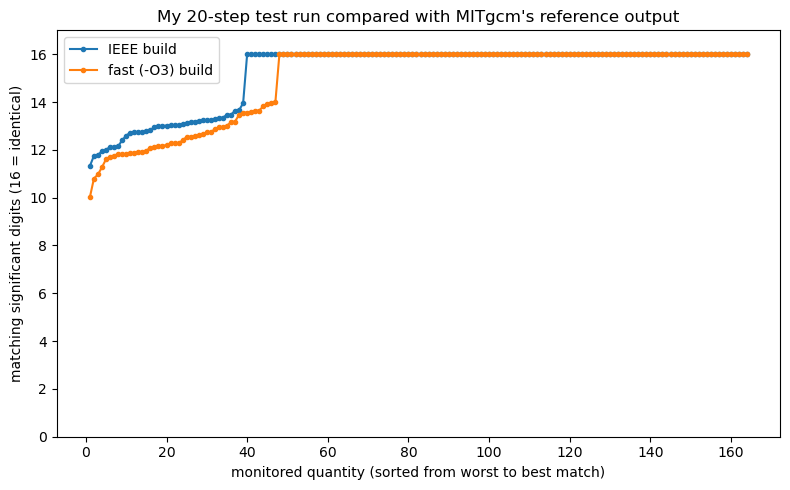

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
for label, cmp, color in [("IEEE build", cmp_ieee, "tab:blue"), ("fast (-O3) build", cmp_fast, "tab:orange")]:
    digits = [d for d, n in cmp if n not in SKIP]
    ax.plot(range(1, len(digits) + 1), digits, "o-", ms=3, color=color, label=label)
ax.set_xlabel("monitored quantity (sorted from worst to best match)")
ax.set_ylabel("matching significant digits (16 = identical)")
ax.set_title("My 20-step test run compared with MITgcm's reference output")
ax.set_ylim(0, 17)
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "01_reference_match.png"), dpi=150)
plt.show()

The monitor prints CFL numbers: how far the flow moves in one time step, as a fraction of a grid cell. If one gets near 1, the model is moving water further than a cell per step and can blow up. I print the largest values from my test run.

In [10]:
cfl_names = [n for n in ours_fast if "cfl" in n.lower()]
for name in cfl_names:
    print(f"{name:24s} max over the run = {max(ours_fast[name]):.4f}")

trAdv_CFL_u_max          max over the run = 0.0547
trAdv_CFL_v_max          max over the run = 0.0273
trAdv_CFL_w_max          max over the run = 0.0721
advcfl_uvel_max          max over the run = 0.0547
advcfl_vvel_max          max over the run = 0.0282
advcfl_wvel_max          max over the run = 0.0805
advcfl_W_hf_max          max over the run = 0.0911


Finally I use the 2-year timing runs to estimate how long the long runs will take. These runs print monitor output once a model year and write no snapshots, roughly like the production runs will.

In [11]:
def wall_seconds(run_dir):
    """Wall-clock seconds from the 'real' line written by /usr/bin/time."""
    for line in open(os.path.join(run_dir, "time.txt")):
        if line.startswith("real"):
            return float(line.split()[1])

timing_years = 2.0
fast_per_year = wall_seconds(TIMING_FAST) / timing_years
ieee_per_year = wall_seconds(TIMING_IEEE) / timing_years
print(f"fast build: {fast_per_year:.2f} s per model year (includes start-up)")
print(f"IEEE build: {ieee_per_year:.2f} s per model year, {ieee_per_year / fast_per_year:.1f} times slower")
for years in [500, 1000, 2000]:
    print(f"  {years:5d} model years with the fast build: about {years * fast_per_year / 3600:.1f} hours")

fast build: 4.54 s per model year (includes start-up)
IEEE build: 49.45 s per model year, 10.9 times slower
    500 model years with the fast build: about 0.6 hours
   1000 model years with the fast build: about 1.3 hours
   2000 model years with the fast build: about 2.5 hours
